# Simulate linearly mixed pixels from satellite sensors

This notebook imports an spectral library and water spectra taken from imagery to then simulate pixels as would be seen by satellite sensors. The number of pixels is user-defined, as are the classes allowed to be simulated into each pixel. For each class, the range of potential fractional percent cover (FPC) and the presence probability are set to default values but can be altered by the user if desired.

### Set up the notebook

In [17]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import linear_mixing as lmx
from random import sample
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Plotting settings and function

plt.rcParams['font.family'] = 'serif' #sans-serif'
colours = {
    "kelp": "gold",
    "brown_algae": "sienna" ,
    "red_veg": "lightcoral",
    "green_veg": "green",
    "mineral" : "grey",
    "water" : "teal",
}

def plot_mixpix_components(pixel_fpcs, colours,  sensor_code, class_code, save = False, output_dir = None, sim_type = "dev"):
    """ 
    Plot the fractional percent cover distributions of the simulated pixels.
    
    """
    if pixel_fpcs.empty:
        ValueError("No valid pixel fractional percent cover data to plot.")
    
    fpcs = pixel_fpcs.copy()
    fpcs["count"] = fpcs.astype(bool).sum(axis=1)

    mat_count = fpcs.shape[1]
    fig, ax = plt.subplots(mat_count//2 + mat_count%2, 2, figsize = (10,(mat_count//2 + mat_count%2)*2), sharey = True)
    fig.tight_layout(pad = 2)

    for col in range(mat_count):
        ax[col//2, col%2].hist(fpcs.iloc[:,col], 
                               bins = 50, 
                               range = (0, max(fpcs.iloc[:, col])), 
                               color = colours.get(fpcs.columns[col], "navy"), log = True)
        annotation = fpcs.columns[col].replace("_", " ").capitalize()
        ax[col//2, col%2].annotate(annotation,  
                                   xy = (0.2, 0.8), 
                                   xycoords = "axes fraction")
        
        if fpcs.columns[col] != "count":
            ax[col//2, col%2].set_xlabel("Fractional Cover")
        else:
            ax[col//2, col%2].set_xlabel("Number of Classes Simulated")
            
        ax[col//2, col%2].set_ylabel("Pixel Count")

    if mat_count % 2 == 1:
        ax[-1, -1].set_visible(False)
    fig.suptitle("Distribution of Simulated Fractional Covers", y = 1.02)
    if save: 
        if not sensor_code or not class_code:
            ValueError("Sensor code and class code must be provided to save the figure.")
        if output_dir is None :
            output_dir = "./"
        
        os.makedirs(output_dir, exist_ok=True)
        filename = f"{sensor_code}_{class_code}_{sim_type}_mixpix_comps_dist.svg"
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches = "tight")
    plt.show()

## User-definable parameters

General settings: directories, pixel counts, sensor choice, class scheme choice

In [19]:
# Where are your spectra?
spec_lib_path = "./data/processed/resampled/noisy_Sentinel_2_ABC_resampled.csv"

# Which sensors and class scheme do you want to use?
sensor_code = "S2"
class_code = "kbrgm"


# How many pixels do you want?
dev_pixel_count = 10000
unseen_pixel_count = 2000


# Do you want to save your plots, and if so, where?
save_plots = True
plot_output_dir = "C:/Users/s4770224/Documents/Work/Writing/Figures/Obj1/part2/"


# Where should simulation results be saved?
sim_pix_directory = f"./data/mixed_sims/{sensor_code}/{class_code}/"
os.makedirs(sim_pix_directory, exist_ok= True)

Granular settings: Which genera should be counted as which classes? Which classes do you want to simulate? How much of each class is allowed in a pixel? How likely is it that a class may be found in a pixel? 

In [ ]:
# Settings for BRGM
# Which classes are being simulated? What genera are in each?
material_options = {
    "brown_algae" : ['ecklonia', 
                     'macrocystis', 
                     'petalonia', 
                     'undaria',
                     'acrocarpia', 
                     'cystophora', 
                     'carpophyllum', 
                     'durvillaea', 
                     'hormosira', 
                     'phyllospora', 
                     'sargassum', 
                     'scytosiphon',
                     ],
    "red_veg" : ['frondose_rhodophyte',
                 'filamentous_rhodophyte'], 
    "green_veg" : ["ulva", "grass"],
    "mineral" : ['barnacle_shells', 
                 'gravel', 
                 'mussels', 
                 'rock', 
                 'sand', 
                 'shell_litter', 
                 'worm_castings'
                 ],
    }

# Assign fractional cover ranges to simulate within
cover_ranges = {
    "brown_algae" : (0, 1),
    "red_veg" : (0,1),
    "green_veg" : (0, 1),
    "mineral" : (0, 1),
    }

# Assign odds of presence for each class ((1, 0) makes 50/50 odds)
presence_odds = {
    "brown_algae" : (1, 0),
    "red_veg" : (1, 0),
    "green_veg" : (1, 0),
    "mineral" : (1, 0),
    }

#Storage of material options
"""
    # "kelp" : ['ecklonia', 
    #           'macrocystis', 
    #           'undaria'],
    # "brown_non_kelp" : ['acrocarpia', 
    #                     'cystophora', 
    #                     'carpophyllum', 
    #                     'durvillaea', 
    #                     'hormosira', 
    #                     'petalonia',
    #                     'phyllospora', 
    #                     'sargassum', 
    #                     'scytosiphon'],
    # "non_brown_autos" : ['grass', 
    #                      'filamentous_rhodophyte', 
    #                      'frondose_rhodophyte',
    #                      'ulva'],
    # "all_non_kelp_autos" : ['acrocarpia', 
    #                         'carpophyllum', 
    #                         'cystophora', 
    #                         'durvillaea', 
    #                         'filamentous_rhodophyte',
    #                         'frondose_rhodophyte', 
    #                         'petalonia', 
    #                         'grass',
    #                         'hormosira',
    #                         'phyllospora',  
    #                         'sargassum',
    #                         'scytosiphon',
    #                         'ulva'],
    # "all_non_kelp" : ['acrocarpia', 
    #                   'barnacle_shells', 
    #                   'carpophyllum',
    #                   'cystophora', 
    #                   'durvillaea', 
    #                   'filamentous_rhodophyte',
    #                   'frondose_rhodophyte', 
    #                   'gravel', 
    #                   'grass',
    #                   'hormosira',
    #                   'mussels',
    #                   'petalonia',
    #                   'phyllospora',
    #                   'rock',
    #                   'sand', 
    #                   'sargassum', 
    #                   'scytosiphon', 
    #                   'shell_litter',
    #                   'rock', 
    #                   'ulva', 
    #                   'worm_castings'],
"""

all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {list(material_options.keys())} " )

In [20]:
# Settings for KBRGM
# Which classes are being simulated? What genera are in each?
material_options = {
     "kelp" : ['ecklonia', 
              'macrocystis', 
              'undaria'],
    "brown_algae" : ['acrocarpia', 
            'cystophora', 
            'carpophyllum', 
            'durvillaea', 
            'hormosira', 
            'petalonia',
            'phyllospora', 
            'sargassum', 
            'scytosiphon'],
    "red_veg" : ['frondose_rhodophyte',
                 'filamentous_rhodophyte'], 
    "green_veg" : ["ulva", "grass"],
    "mineral" : ['barnacle_shells', 
                 'gravel', 
                 'mussels', 
                 'rock', 
                 'sand', 
                 'shell_litter', 
                 'worm_castings'
                 ],
    }

# Assign fractional cover ranges to simulate within
cover_ranges = {
    "kelp": (0,1),
    "brown_algae" : (0, 1),
    "red_veg" : (0,1),
    "green_veg" : (0, 1),
    "mineral" : (0, 1),
    }

# Assign odds of presence for each class ((1, 0) makes 50/50 odds)
presence_odds = {
    "kelp" : (1, 0),
    "brown_algae" : (1, 0),
    "red_veg" : (1, 0),
    "green_veg" : (1, 0),
    "mineral" : (1, 0),
    }



all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {list(material_options.keys())} " )

Classes to be simulated : ['kelp', 'brown_algae', 'red_veg', 'green_veg', 'mineral'] 


In [ ]:
# Settings for BO (browns detection)
# Which classes are being simulated? What genera are in each?
material_options = {
    "brown_algae" : ['ecklonia', 
                     'macrocystis', 
                     'petalonia', 
                     'undaria',
                     'acrocarpia', 
                     'cystophora', 
                     'carpophyllum', 
                     'durvillaea', 
                     'hormosira', 
                     'phyllospora', 
                     'sargassum', 
                     'scytosiphon',
                     ],
    "other" : ['barnacle_shells', 
               'filamentous_rhodophyte',
               'frondose_rhodophyte', 
               'gravel', 
               'grass',
               'mussels',
               'sand', 
               'shell_litter',
               'rock', 
               'ulva', 
               'worm_castings'],
    }

# Assign fractional cover ranges to simulate within
cover_ranges = {
    "brown_algae" : (0, 1),
    "other" : (0,1),
    }

# Assign odds of presence for each class ((1, 0) makes 50/50 odds)
presence_odds = {
    "brown_algae" : (1, 0),
    "other" : (1, 0),
    }

all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {list(material_options.keys())} " )

In [ ]:
#Settings for all materials by class
all = ['ecklonia', 
'macrocystis', 
'undaria',
'acrocarpia', 
'barnacle_shells', 
'carpophyllum',
'cystophora', 
'durvillaea', 
'filamentous_rhodophyte',
'frondose_rhodophyte', 
'gravel', 
'grass',
'hormosira',
'mussels',
'petalonia',
'phyllospora', 
'rock',
'sand', 
'sargassum', 
'scytosiphon', 
'shell_litter',
'rock', 
'ulva', 
'worm_castings']

material_options = {x:[x] for x in all}
cover_ranges = {x:(0,1) for x in all}
presence_odds = {x:(1,0) for x in all}

all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {list(material_options.keys())} " )

In [ ]:
# Settings for browns by genus versus other materials
material_options =  {'ecklonia': ['ecklonia'], 
                     'macrocystis': ['macrocystis'], 
                     'undaria': ['undaria'], 
                     'acrocarpia': ['acrocarpia'], 
                     'carpophyllum': ['carpophyllum'], 
                     'cystophora': ['cystophora'], 
                     'durvillaea': ['durvillaea'], 
                     'hormosira': ['hormosira'], 
                     'petalonia': ['petalonia'], 
                     'phyllospora': ['phyllospora'], 
                     'sargassum': ['sargassum'], 
                     'scytosiphon': ['scytosiphon'], 
                     'other': ['barnacle_shells', 
                      'filamentous_rhodophyte',
                      'frondose_rhodophyte', 
                      'gravel', 
                      'grass',
                      'mussels',
                      'rock',
                      'sand', 
                      'shell_litter',
                      'rock', 
                      'ulva', 
                      'worm_castings']
                     }


cover_ranges = {'ecklonia': (0, 1),
                'macrocystis': (0, 1),
                'undaria': (0, 1),
                'acrocarpia': (0, 1),
                'carpophyllum': (0, 1),
                'cystophora': (0, 1),
                'durvillaea': (0, 1),
                'hormosira': (0, 1),
                'petalonia': (0, 1),
                'phyllospora': (0, 1),
                'sargassum': (0, 1),
                'scytosiphon': (0, 1),
                'other': (0, 1)}

presence_odds = {'ecklonia': (3, 3),        #(3, 7) = 0% chance of inclusion
                 'macrocystis': (3, 3),     #(3, 1) = 75% chance of inclusion
                 'undaria': (3, 3),         #(3, 3) = 50% chance of inclusion
                 'acrocarpia': (3, 1),      #(3, 0) = 87.5% chance of inclusion
                 'carpophyllum': (3, 1),    #(3, 6) = 12.5% chance of inclusion
                 'cystophora': (3, 1),
                 'durvillaea': (3, 1),
                 'hormosira': (3, 6),
                 'petalonia': (3, 6),
                 'phyllospora': (3, 3),
                 'sargassum': (3, 2),
                 'scytosiphon': (3, 6),
                 'other': (3, 0)}

all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {list(material_options.keys())} " )

In [ ]:
# Settings for macro-eck-durv-mineral
material_options =  {'ecklonia': ['ecklonia'], 
                     'macrocystis': ['macrocystis'], 
                     'durvillaea': ['durvillaea'], 
                     'mineral': ['gravel', 
                      'rock',
                      'sand', "worm_castings", "barnacles", "mussels", "shell_litter"]}


cover_ranges = {'ecklonia': (0, 1),
                'macrocystis': (0, 1),
                'durvillaea': (0, 1),
                'mineral': (0, 1)}

presence_odds = {'ecklonia': (3, 3),        #(3, 7) = 0% chance of inclusion
                 'macrocystis': (3, 3),     #(3, 1) = 75% chance of inclusion
                 'durvillaea': (3, 3),
                 'mineral': (3, 3)}

all_allowed = []
for item in material_options.items():
    all_allowed += item[1]
    
print(f"Classes to be simulated : {list(material_options.keys())} " )

## Load the endmember and water data

In [21]:
# Load spectral data from file and prep

data = pd.read_csv(spec_lib_path, index_col=0)
labels = pd.read_csv("data/labels_prepped.csv", index_col=0)
data = pd.concat([labels["Class"], data], axis = 1)
data = data [data["Class"].isin(all_allowed)]
labels = labels[labels["Class"].isin(all_allowed)]
labels["brgm"] = labels["kbrgm"].replace(["kelp", "other_brown_alg"], "brown_algae")
labels["bo"] = labels["brgm"].replace(["red_veg", "green_veg", "mineral"], "other")
labels["bo_genus"] = labels["Class"].replace(['barnacle_shells', 'filamentous_rhodophyte','frondose_rhodophyte', 'gravel', 'grass','mussels','rock','sand', 'shell_litter','rock', 'ulva', 'worm_castings'], "other")
labels["medm"] = labels["Class"].replace(['gravel', 'rock','sand'], "other")

### Prepare the water spectra

Inspect the water spectra and clusters at bottom of notebook

In [22]:
# Load and prepare water pixel spectra from file

if sensor_code =="S2":
    deep_waters = pd.read_csv("../../Work/geospatial_analysis/water_sampling/Sen2/S2_deep_water_agg.csv", index_col=0)
    deep_waters["depth"] = "deep"

    # Load shallow water
    shallow_waters = pd.read_csv("../../Work/geospatial_analysis/water_sampling/Sen2/S2_shallow_agg.csv", index_col=0)
    shallow_waters["depth"] = "shallow"

    # combine all water pixels and separate into metadata and spectra
    all_waters = pd.concat([deep_waters, shallow_waters], 
                    axis = 0, ignore_index= True).reset_index(drop = True)
    water_spec = all_waters.iloc[:, 4:-4]
    water_meta = pd.concat([all_waters.iloc[:, :4], all_waters.iloc[:, -4:]], axis = 1)   
elif sensor_code.lower() == "enm":
    water_spec = pd.read_csv("../../Work/geospatial_analysis/water_sampling/Enmap/Enmap_pixel_samples.csv")
    water_spec.head()

    # get rid of bands outside of endmember spectral range
    water_spec = water_spec.iloc[:, 8:86] 

    # Remove bad data from QGIS export
    a = water_spec.values
    b = (a == a[[0], :]).all(axis=0)
    c = (a == a[:, [0]]).all(axis=1)

    water_spec = water_spec.loc[c==0, b==0]
    water_meta = water_spec.index.to_frame()
elif sensor_code.lower() == "psd":
    # Load and prepare water pixel spectra from file
    water_spec = pd.read_csv("../../Work/geospatial_analysis/water_sampling/planet/planet_pixel_sample_1M.csv")

    # get rid of bands outside of endmember spectral range
    water_spec = water_spec.iloc[:, 1:] 

    # Remove bad data from QGIS export
    a = water_spec.values
    b = (a == a[[0], :]).all(axis=0)
    c = (a == a[:, [0]]).all(axis=1)

    water_spec = water_spec.loc[c==0, b==0]
    water_meta = water_spec.index.to_frame()
else:
    print("Sensor code not recognised. Please use S2, ENM, or PSD.")

print(f"Total of {water_spec.shape[0]} water pixels loaded")
water_spec.columns = data.columns[1:]
# De-duplicate water spectra
water_spec.drop_duplicates(inplace = True)
water_meta = water_meta.loc[water_spec.index]
print(f"Total of {water_spec.shape[0]} unique water pixels")

water_spec = water_spec/10000  # Convert to reflectance

Total of 1444429 water pixels loaded
Total of 770258 unique water pixels


## Separate the endmembers and mix pixels

Two sets of pixels will be made: model development pixels (training/testing) and validation pixels (refered to as "unseen pixels" later)

In [23]:
# Split spectra into training and testing sets
data_train, data_test = train_test_split(data, test_size = 0.3, stratify=labels[class_code])

water_train, water_test = train_test_split(water_spec, test_size = 0.3)
water_meta_train = water_meta.loc[water_train.index]
water_meta_test = water_meta.loc[water_test.index]

### Simulate the development pixels

In [24]:
# Instantiate the pixel mixer
mixer = lmx.LinearMixing(materials = material_options, 
                         cover_ranges = cover_ranges, 
                         pixels = dev_pixel_count,
                         odds_dict = presence_odds,
                         material_spectra= data_train, 
                         water_spectra = water_train)

# Mix pixels and store results
results, f, endmember_indices = mixer.sim_many_pixels()

# Format results and clear old variables
sim_pix, pixel_fpcs, endmember_indices = mixer.format_sim_results(results, f, endmember_indices)
del results, f

# Inspect simulated results
print(f"{sim_pix.shape[0]} simulated pixels with {sim_pix.shape[1]} spectral bands \n")
print(f"Preview of simulated component fractional covers: \n {pixel_fpcs.head(3)}")


10000 simulated pixels with 8 spectral bands 

Preview of simulated component fractional covers: 
        kelp  brown_algae   red_veg  green_veg   mineral     water
0  0.000000     0.000000  0.000000   0.000000  0.000000  1.000000
1  0.000000     0.000000  0.052849   0.721809  0.222169  0.003172
2  0.058782     0.089588  0.000000   0.396649  0.000000  0.454981


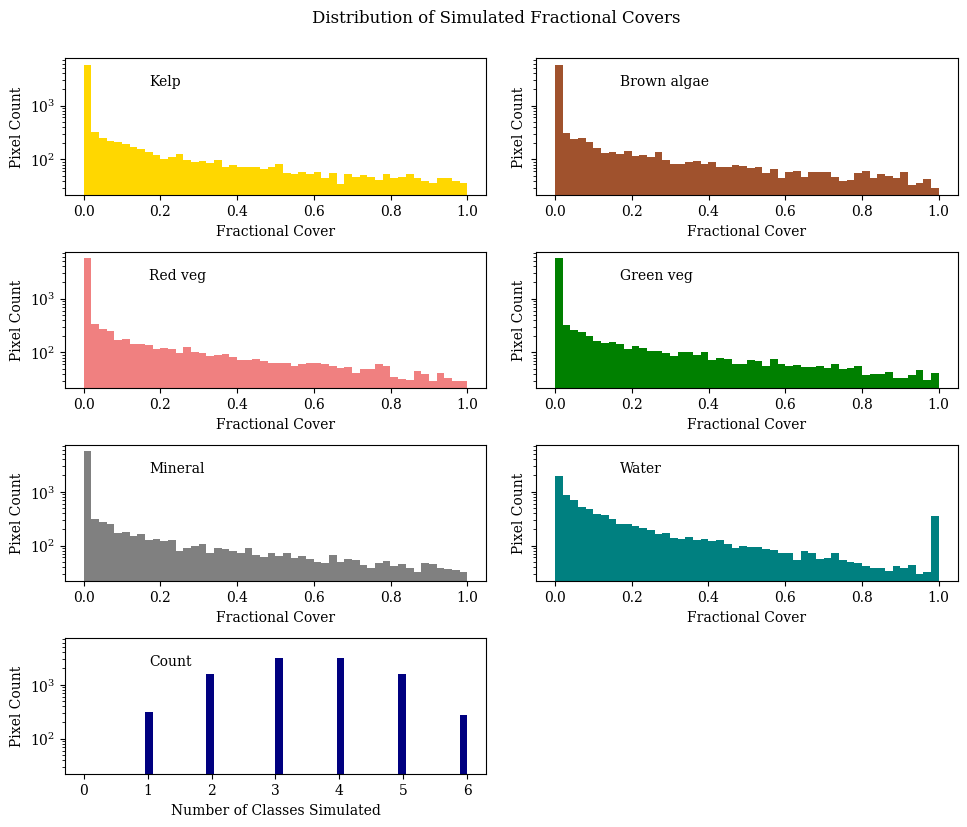

In [25]:
# Plot the components of the simulated pixels      
plot_mixpix_components(pixel_fpcs, colours, sensor_code= sensor_code, class_code = class_code, save = save_plots, output_dir = plot_output_dir, sim_type= "dev")

In [26]:
# Export the simulated development pixels
np.save(sim_pix_directory + "development_pixels.npy", sim_pix)
np.save(sim_pix_directory + "development_pixels_columns.npy", pixel_fpcs.columns, allow_pickle = True)
np.save(sim_pix_directory+ "development_pixel_fpcs.npy", pixel_fpcs)
np.save(sim_pix_directory + "development_pixel_endmembers.npy", endmember_indices)
np.save(sim_pix_directory + "data_train_indices.npy", data_train.index)

### Simulate the unseen pixels

In [27]:
# Instantiate the pixel mixer
mixer = lmx.LinearMixing(materials = material_options, 
                         cover_ranges = cover_ranges, 
                         pixels = unseen_pixel_count, 
                         material_spectra= data_test,
                         odds_dict= presence_odds, 
                         water_spectra = water_test)

# Mix pixels and store results
new_results, new_f, new_endmember_indices = mixer.sim_many_pixels()

# Format results and clear old variables
new_mixpix, new_pixel_fpcs, new_endmembers = mixer.format_sim_results(new_results, new_f, new_endmember_indices)
del new_results, new_f, new_endmember_indices


# Inspect simulated results
print(f"{new_mixpix.shape[0]} pixels simulated with {new_mixpix.shape[1]} spectral bands \n")
print(new_pixel_fpcs.head())

2000 pixels simulated with 8 spectral bands 

       kelp  brown_algae   red_veg  green_veg   mineral     water
0  0.000000     0.198409  0.000000   0.000000  0.538418  0.263173
1  0.000000     0.000000  0.046434   0.738577  0.000000  0.214990
2  0.000309     0.983733  0.000140   0.000000  0.015813  0.000005
3  0.000000     0.000000  0.359304   0.000000  0.472123  0.168574
4  0.000000     0.000000  0.000000   0.157181  0.000000  0.842819


In [28]:
# Save the unseen pixels 

np.save(sim_pix_directory + "unseen_pixels.npy", new_mixpix)
np.save(sim_pix_directory + "unseen_pixel_fpcs.npy", new_pixel_fpcs)
np.save(sim_pix_directory + "unseen_pixel_endmembers.npy", new_endmembers)
np.save(sim_pix_directory + "data_test_indices.npy", data_test.index)

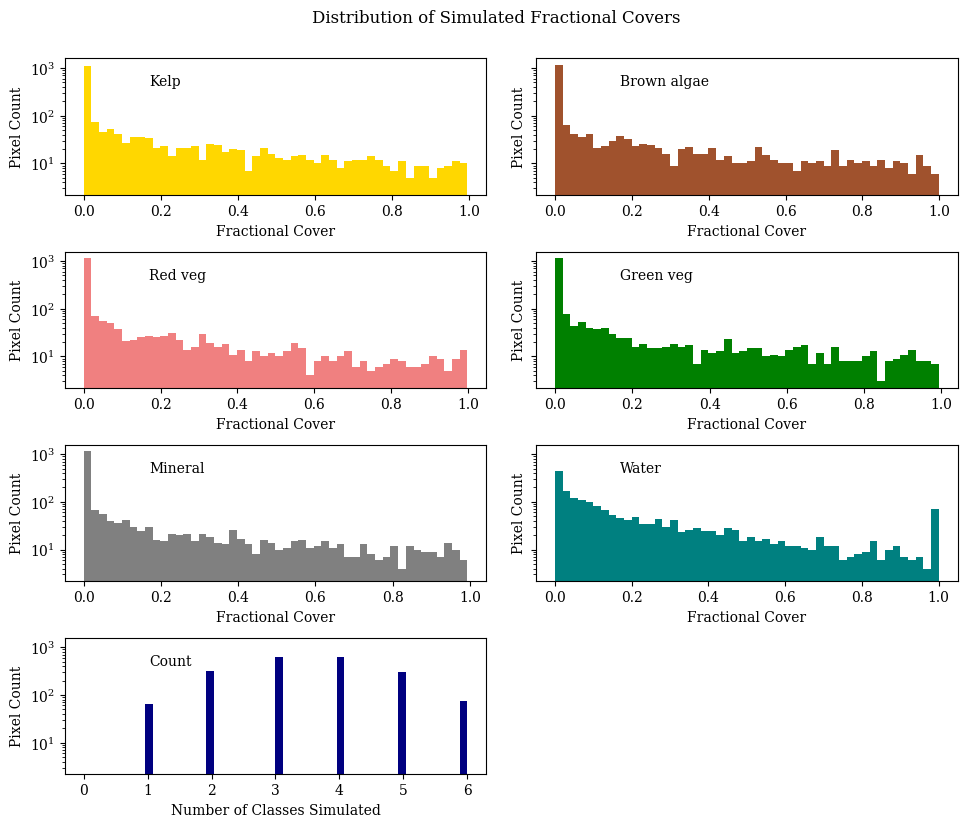

In [29]:
# Plot the components of the simulated pixels      
plot_mixpix_components(new_pixel_fpcs, colours, sensor_code= sensor_code, class_code = class_code, save = save_plots, output_dir = plot_output_dir, sim_type= "unseen")

# Examine the endmembers and water spectra

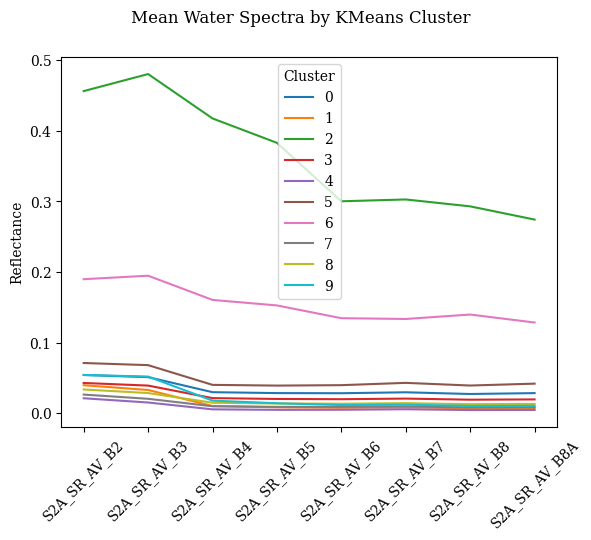

In [30]:
# Examine the water spectra being used

x = StandardScaler().fit_transform(water_spec)

clusters = KMeans(n_clusters = 10, n_init ='auto').fit(x)
water_meta["cluster"] = clusters.labels_
water_spec.groupby(water_meta["cluster"]).mean().T.plot()
plt.xticks(rotation = 45)
plt.suptitle("Mean Water Spectra by KMeans Cluster")
plt.ylabel("Reflectance")
plt.legend(title = "Cluster", loc = "best")
plt.show()

# Clustering water spectra

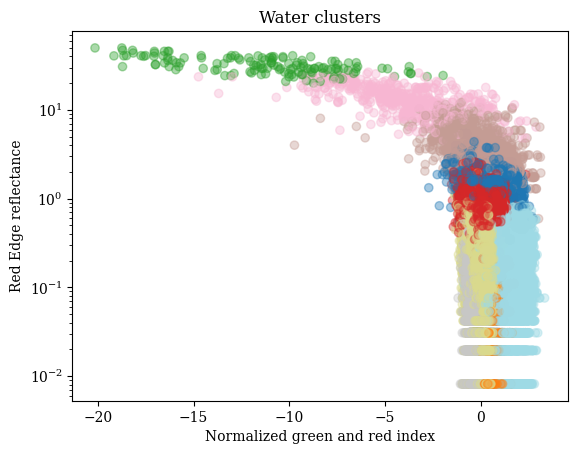

In [31]:
# plot kmeans clusters
plt.scatter((x[:, 1] - x[:, 2]), x[:, 4], c = water_meta["cluster"], cmap = "tab20", alpha = 0.4)
# plt.scatter((x[:, 20]-x[:, 4]), (x[:, 29]-x[:, -9])/(x[:, 29]+x[:, -9]), c = water_meta["cluster"], cmap = "tab20", alpha = 0.4)        #ENMAP 
plt.yscale("log")
plt.ylabel("Red Edge reflectance")
plt.xlabel( "Normalized green and red index")

plt.title("Water clusters")
plt.show()

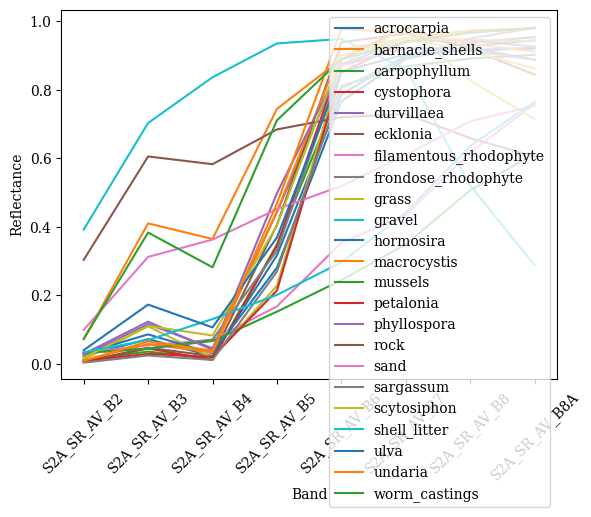

In [32]:
# plot mean endmember spectra 

# labels["brgm"] = labels["kbrgm"].replace(to_replace=["kelp", "other_brown_alg"], value = "browns")
endmembers = pd.DataFrame(data.iloc[:, 1:]).groupby(labels["Class"]).mean()

plt.plot(endmembers.T)
plt.legend(endmembers.index)
plt.xticks(rotation = 45)
plt.ylabel("Reflectance")
plt.xlabel("Band")  
plt.show()